In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [5]:
train_path = "MRI DS/Training"
test_path = "MRI DS/Testing"

In [6]:
import os

print("Training Path Exists:", os.path.exists(train_path))
print("Testing Path Exists:", os.path.exists(test_path))

Training Path Exists: True
Testing Path Exists: True


In [7]:
classes = os.listdir(train_path)

print("Classes in Training Dataset:")
for cls in classes:
    print(cls)

Classes in Training Dataset:
glioma
meningioma
notumor
pituitary


In [8]:
print("Number of images in each class:\n")

for cls in classes:
    path = os.path.join(train_path, cls)
    count = len(os.listdir(path))
    print(f"{cls}: {count}")

Number of images in each class:

glioma: 1400
meningioma: 1400
notumor: 1400
pituitary: 1400


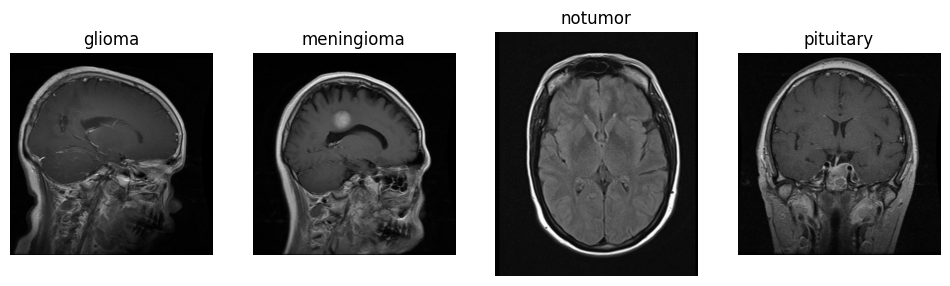

In [9]:
plt.figure(figsize=(12,4))

for i, cls in enumerate(classes):
    folder = os.path.join(train_path, cls)

    image_name = random.choice(os.listdir(folder))
    image_path = os.path.join(folder, image_name)

    image = Image.open(image_path)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(image, cmap='gray')
    plt.title(cls)
    plt.axis("off")

plt.show()

In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [32]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

In [33]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 4480 images belonging to 4 classes.


In [13]:
validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 1120 images belonging to 4 classes.


In [34]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [15]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 75s 1us/step


In [35]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

In [36]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [37]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [38]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [19]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [39]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop, checkpoint]
) 

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 662s 5s/step - accuracy: 0.5585 - loss: 1.0029 - val_accuracy: 0.2732 - val_loss: 1.3310
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 568s 4s/step - accuracy: 0.6734 - loss: 0.8016 - val_accuracy: 0.6036 - val_loss: 0.8736
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 517s 4s/step - accuracy: 0.6875 - loss: 0.7511 - val_accuracy: 0.7259 - val_loss: 0.6467
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 507s 4s/step - accuracy: 0.7054 - loss: 0.7216 - val_accuracy: 0.7312 - val_loss: 0.6510
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 578s 4s/step - accuracy: 0.7190 - loss: 0.6841 - val_accuracy: 0.7000 - val_loss: 0.6750
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 555s 4s/step - accuracy: 0.7335 - loss: 0.6563 - val_accuracy: 0.6348 - val_loss: 0.8513
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 593s 4s/step - accuracy: 0.7446 - loss: 0.6288 - val_accuracy: 0.7018 - val_loss: 0.7106
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 508s 4s/step - accuracy: 0.7493 - loss: 0.6284 - val_accu

In [21]:
model.save("brain_tumor_resnet50.keras")

In [42]:
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

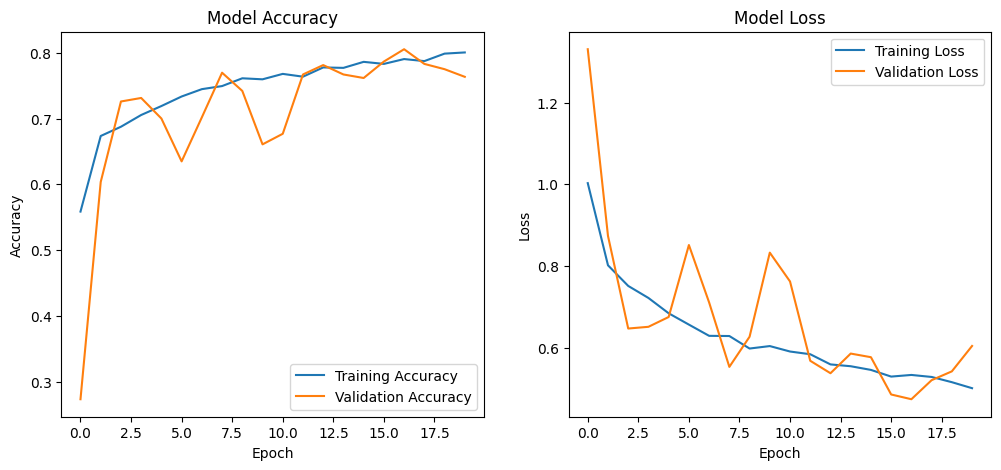

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [44]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1600 images belonging to 4 classes.


In [45]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.7487 - loss: 0.7516
Test Accuracy: 0.7487499713897705
Test Loss: 0.7515810132026672


In [25]:
print("Training Accuracy:", history.history['accuracy'])
print("Validation Accuracy:", history.history['val_accuracy'])

print("\nTraining Loss:", history.history['loss'])
print("Validation Loss:", history.history['val_loss'])

Training Accuracy: [0.4647321403026581, 0.5718749761581421, 0.6044642925262451, 0.6428571343421936, 0.6540178656578064, 0.6595982313156128, 0.6736606955528259, 0.6814731955528259, 0.6926339268684387, 0.6785714030265808]
Validation Accuracy: [0.5571428537368774, 0.6258928775787354, 0.6169642806053162, 0.6901785731315613, 0.6392857432365417, 0.6892856955528259, 0.6875, 0.6991071701049805, 0.7196428775787354, 0.7116071581840515]

Training Loss: [1.1967805624008179, 1.030173897743225, 0.9531682729721069, 0.8966858386993408, 0.8582292199134827, 0.8307981491088867, 0.8067995309829712, 0.7866904735565186, 0.7655953168869019, 0.764934241771698]
Validation Loss: [1.0361205339431763, 0.9558525085449219, 0.8876475691795349, 0.8229084610939026, 0.8441202640533447, 0.7849159240722656, 0.7735960483551025, 0.7501084208488464, 0.7108318209648132, 0.7116369009017944]
